### Processing and Augmentation

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from PIL import Image

from torch.utils.data import DataLoader

In [2]:
# Path to the project root directory
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_PATH = (
    PROCESSED_DATA_DIR
    / "train.csv"
)

VAL_PATH = (
    PROCESSED_DATA_DIR
    / "val.csv"
)

TEST_PATH = (
    PROCESSED_DATA_DIR
    / "test.csv"
)

print(
    "Project root:",
    PROJECT_ROOT
)

Project root: d:\Deep Learning\skin-lesion-classification


In [3]:
# Import project modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(
        str(PROJECT_ROOT)
    )

from src.data.preprocessing import (
    get_eval_transform,
    denormalize_tensor,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
    CLASS_TO_IDX,
    IDX_TO_CLASS,
)

In [4]:
# Load fixed split 
train_df = pd.read_csv(
    TRAIN_PATH
)

val_df = pd.read_csv(
    VAL_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)

print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)

Train      : 6,981
Validation : 1,532
Test       : 1,502


In [5]:
# Varify split label
print(
    "Train split values:",
    train_df["split"].unique()
)

print(
    "Validation split values:",
    val_df["split"].unique()
)

print(
    "Test split values:",
    test_df["split"].unique()
)

Train split values: ['train']
Validation split values: ['val']
Test split values: ['test']


In [6]:
# Label encoding
print(
    "Class mapping:"
)

for class_name, class_idx in CLASS_TO_IDX.items():

    print(
        f"{class_name:<8}"
        f" -> {class_idx}"
    )



Class mapping:
akiec    -> 0
bcc      -> 1
bkl      -> 2
df       -> 3
mel      -> 4
nv       -> 5
vasc     -> 6


In [7]:
# Define image size 
IMAGE_SIZE = 224

print(
    "Target image size:",
    IMAGE_SIZE,
    "x",
    IMAGE_SIZE,
)

Target image size: 224 x 224


In [8]:
# Create transformations
train_transform = (
    get_train_transform(
        image_size=IMAGE_SIZE
    )
)

eval_transform = (
    get_eval_transform(
        image_size=IMAGE_SIZE
    )
)

print(
    "TRAIN TRANSFORM:"
)

print(
    train_transform
)

print(
    "\nVAL/TEST TRANSFORM:"
)

print(
    eval_transform
)

TRAIN TRANSFORM:
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

VAL/TEST TRANSFORM:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


Original size: (600, 450)
Diagnosis: bkl


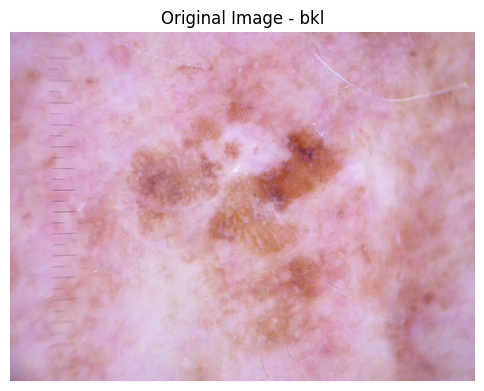

In [9]:
# Visual original images
sample_row = train_df.iloc[0]

sample_path = Path(
    sample_row["image_path"]
)

if not sample_path.is_absolute():

    sample_path = (
        PROJECT_ROOT
        / sample_path
    )

image = Image.open(
    sample_path
).convert("RGB")

print(
    "Original size:",
    image.size
)

print(
    "Diagnosis:",
    sample_row["dx"]
)

plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    image
)

plt.title(
    f"Original Image - {sample_row['dx']}"
)

plt.axis(
    "off"
)

plt.show()

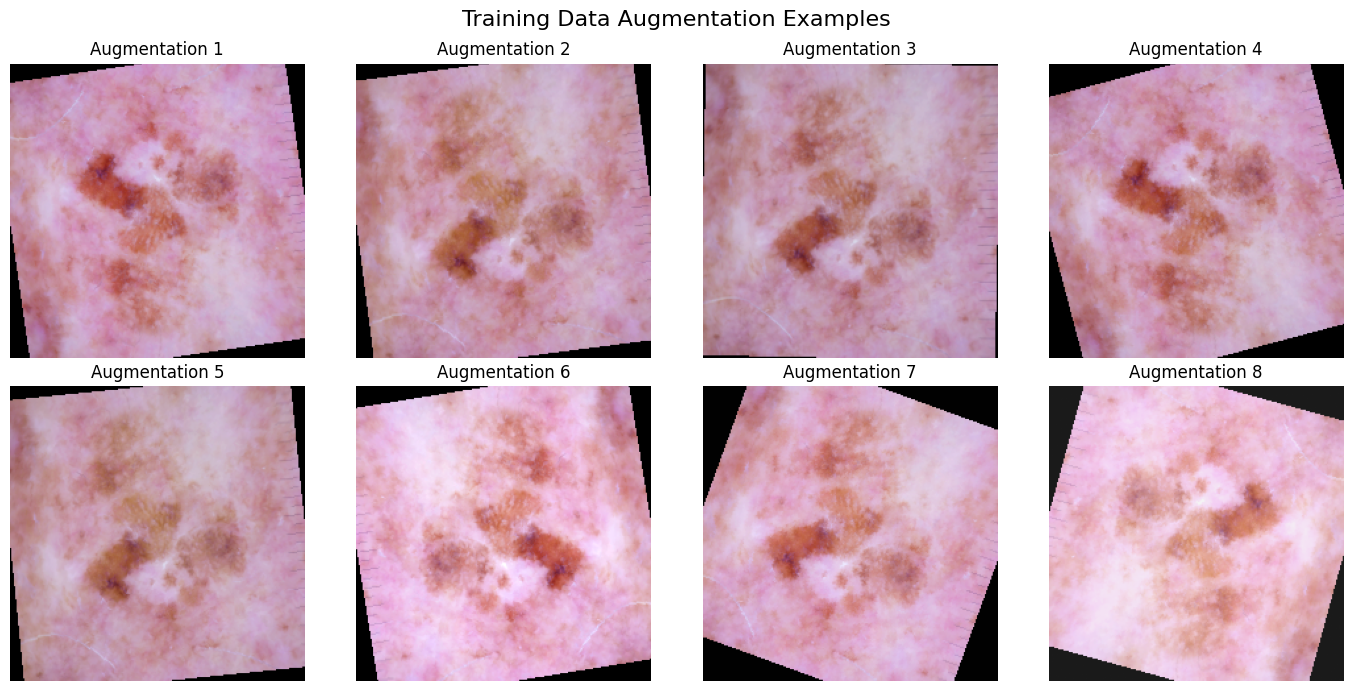

In [10]:
# Visual augmented images
NUM_AUGMENTATIONS = 8

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)

axes = axes.flatten()

for i in range(
    NUM_AUGMENTATIONS
):

    augmented_tensor = (
        train_transform(
            image
        )
    )

    augmented_image = (
        denormalize_tensor(
            augmented_tensor
        )
    )

    augmented_image = (
        augmented_image
        .permute(1, 2, 0)
        .numpy()
    )

    axes[i].imshow(
        augmented_image
    )

    axes[i].set_title(
        f"Augmentation {i + 1}"
    )

    axes[i].axis(
        "off"
    )

plt.suptitle(
    "Training Data Augmentation Examples",
    fontsize=16,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "augmentation_examples.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

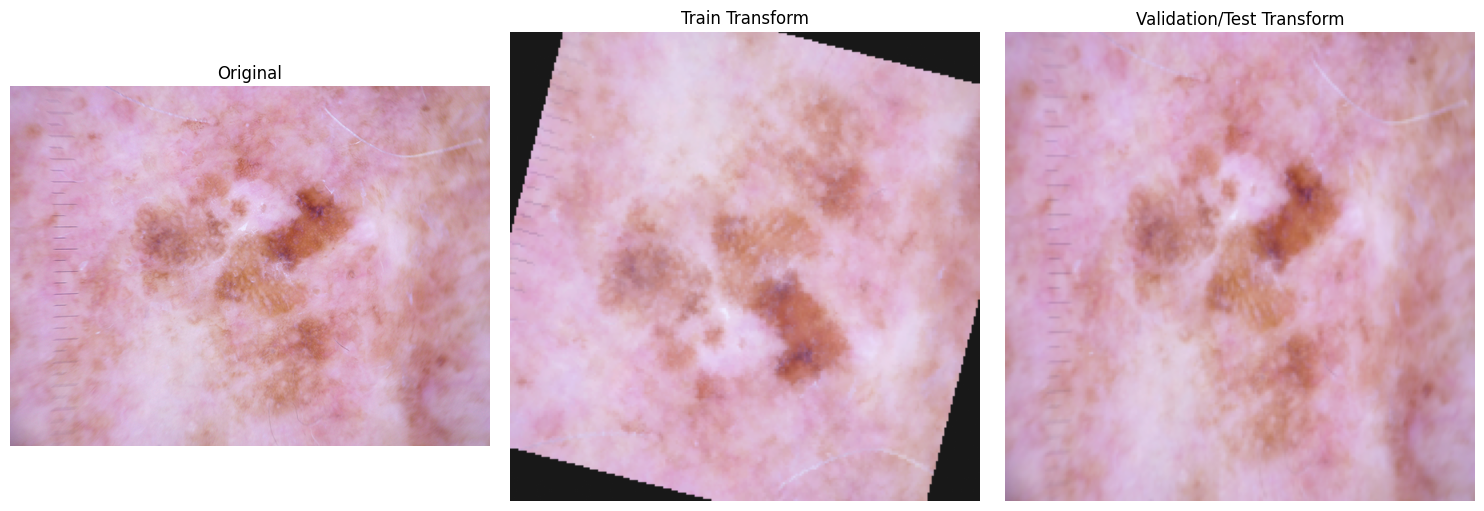

In [11]:
# Compare train and validation/test transformations
train_tensor = (
    train_transform(
        image
    )
)

eval_tensor = (
    eval_transform(
        image
    )
)

train_image = (
    denormalize_tensor(
        train_tensor
    )
    .permute(1, 2, 0)
    .numpy()
)

eval_image = (
    denormalize_tensor(
        eval_tensor
    )
    .permute(1, 2, 0)
    .numpy()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

axes[0].imshow(
    image
)

axes[0].set_title(
    "Original"
)

axes[1].imshow(
    train_image
)

axes[1].set_title(
    "Train Transform"
)

axes[2].imshow(
    eval_image
)

axes[2].set_title(
    "Validation/Test Transform"
)

for ax in axes:
    ax.axis(
        "off"
    )

plt.tight_layout()
plt.show()

In [12]:
# Create Pytorch datasets 
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

print(
    f"Train dataset      : {len(train_dataset):,}"
)

print(
    f"Validation dataset : {len(val_dataset):,}"
)

print(
    f"Test dataset       : {len(test_dataset):,}"
)

Train dataset      : 6,981
Validation dataset : 1,532
Test dataset       : 1,502


In [13]:
# Inspect single dataset sample
image_tensor, label = (
    train_dataset[0]
)

print(
    "Image tensor shape:",
    image_tensor.shape
)

print(
    "Image dtype:",
    image_tensor.dtype
)

print(
    "Label:",
    label.item()
)

print(
    "Class:",
    IDX_TO_CLASS[
        label.item()
    ]
)

Image tensor shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 2
Class: bkl


In [15]:
# Check transformed tensor statistics
print(
    "Tensor minimum:",
    image_tensor.min().item()
)

print(
    "Tensor maximum:",
    image_tensor.max().item()
)

print(
    "Tensor mean:",
    image_tensor.mean().item()
)

print(
    "Tensor std:",
    image_tensor.std().item()
)

Tensor minimum: -2.1179039478302
Tensor maximum: 2.395991325378418
Tensor mean: 0.9806868433952332
Tensor std: 0.6530103087425232


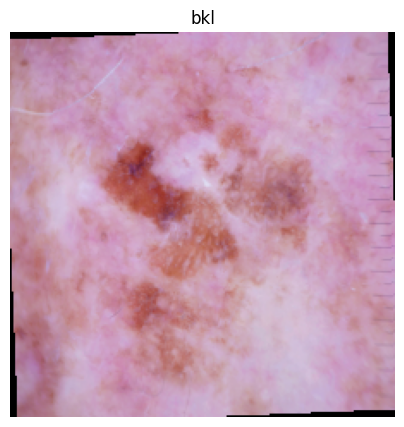

In [16]:
# Visual dataset sample after processing 
display_tensor = (
    denormalize_tensor(
        image_tensor
    )
)

display_image = (
    display_tensor
    .permute(1, 2, 0)
    .numpy()
)

plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    display_image
)

plt.title(
    IDX_TO_CLASS[
        label.item()
    ]
)

plt.axis(
    "off"
)

plt.show()

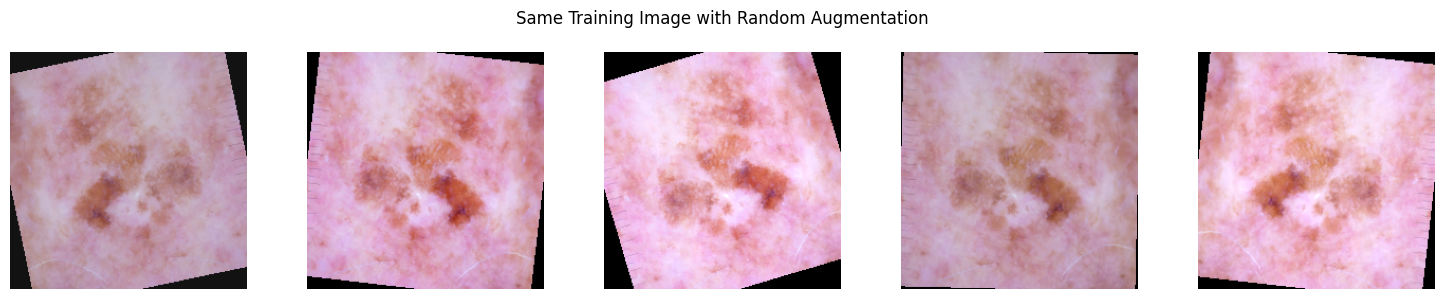

In [17]:
# Test random augmentation behavior => Một ảnh khi train nhiều lần sẽ ra nhiều ảnh khác nhau
fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 3),
)

for i in range(5):

    image_tensor, label = (
        train_dataset[0]
    )

    display_image = (
        denormalize_tensor(
            image_tensor
        )
        .permute(1, 2, 0)
        .numpy()
    )

    axes[i].imshow(
        display_image
    )

    axes[i].axis(
        "off"
    )

plt.suptitle(
    "Same Training Image with Random Augmentation"
)

plt.tight_layout()
plt.show()


In [18]:
# Verify Validation transform is deterministic => Một ảnh khi val nhiều lần sẽ ra cùng 1 ảnh
image_a, label_a = (
    val_dataset[0]
)

image_b, label_b = (
    val_dataset[0]
)

difference = torch.abs(
    image_a - image_b
).max()

print(
    "Maximum difference:",
    difference.item()
)

assert torch.equal(
    image_a,
    image_b
)

print(
    "Validation transform is deterministic."
)

Maximum difference: 0.0
Validation transform is deterministic.


In [ ]:
# Verify Test transform is deterministic => Một ảnh khi test nhiều lần sẽ ra cùng 1 ảnh
image_a, label_a = (
    test_dataset[0]
)

image_b, label_b = (
    test_dataset[0]
)

assert torch.equal(
    image_a,
    image_b
)

print(
    "Test transform is deterministic."
)

In [19]:
# Create DataLoaders
BATCH_SIZE = 32

NUM_WORKERS = 0
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

In [20]:
# Inspect a batch of data
images, labels = next(
    iter(train_loader)
)

print(
    "Images batch shape:",
    images.shape
)

print(
    "Labels batch shape:",
    labels.shape
)

print(
    "Image dtype:",
    images.dtype
)

print(
    "Label dtype:",
    labels.dtype
)

Images batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


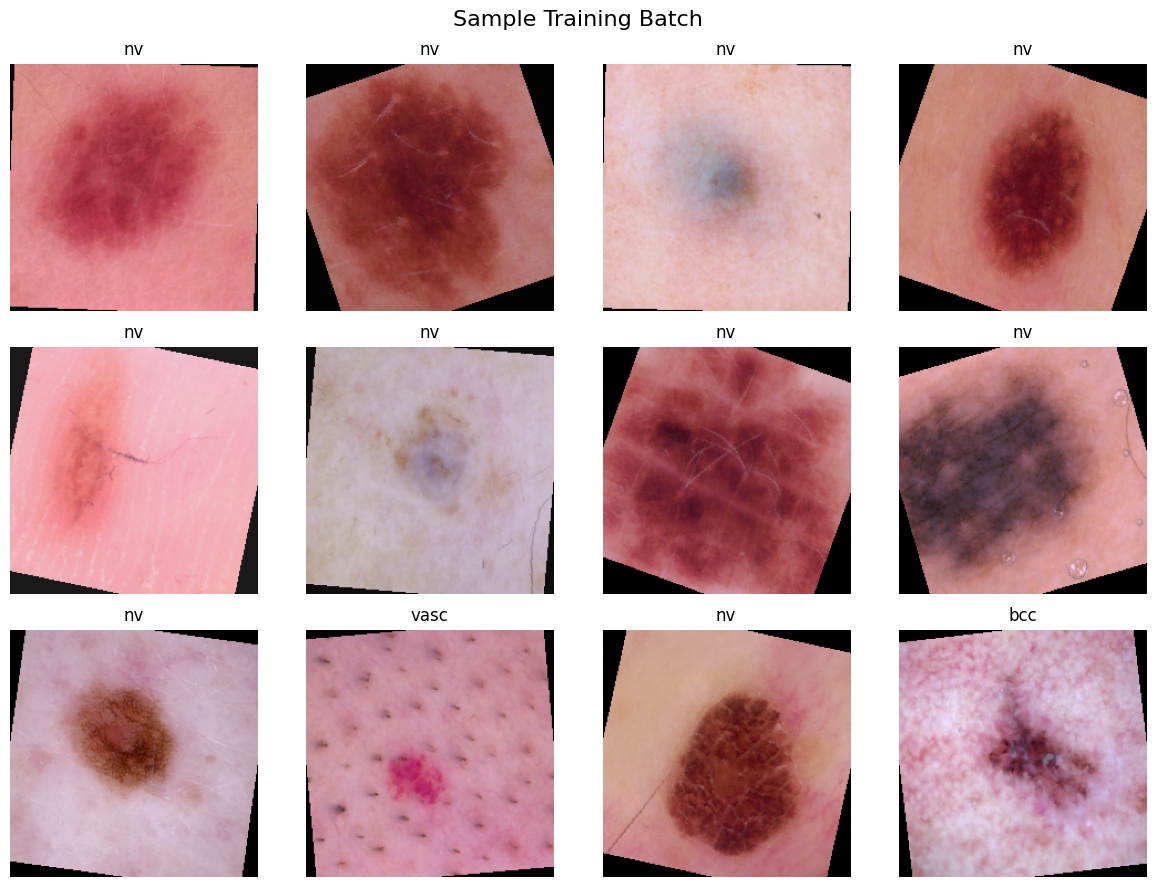

In [21]:
# Visual a batch of images
NUM_DISPLAY = 12

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9),
)

axes = axes.flatten()

for i in range(
    min(NUM_DISPLAY, len(images))
):

    image = (
        denormalize_tensor(
            images[i]
        )
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    label_idx = (
        labels[i].item()
    )

    axes[i].imshow(
        image
    )

    axes[i].set_title(
        IDX_TO_CLASS[
            label_idx
        ]
    )

    axes[i].axis(
        "off"
    )

plt.suptitle(
    "Sample Training Batch",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [22]:
# Validate every class mapping
assert len(
    CLASS_TO_IDX
) == 7

assert len(
    IDX_TO_CLASS
) == 7

for class_name in HAM10000_CLASSES:

    assert (
        class_name
        in CLASS_TO_IDX
    )

print(
    "All 7 classes are correctly encoded."
)

All 7 classes are correctly encoded.


In [23]:
# Check dataset class 
for split_name, dataframe in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    classes = sorted(
        dataframe["dx"].unique()
    )

    print(
        f"{split_name:<12}:",
        classes
    )

train       : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
validation  : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
test        : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [24]:
# Class imbalance 
train_class_counts = (
    train_df["dx"]
    .value_counts()
    .reindex(
        HAM10000_CLASSES
    )
)

train_class_counts

dx
akiec     222
bcc       361
bkl       772
df         71
mel       773
nv       4683
vasc       99
Name: count, dtype: int64

In [25]:
# Calculate class weights for imbalanced dataset
num_samples = len(
    train_df
)

num_classes = len(
    HAM10000_CLASSES
)

class_weights = []

for class_name in HAM10000_CLASSES:

    class_count = (
        train_class_counts[
            class_name
        ]
    )

    weight = (
        num_samples
        / (
            num_classes
            * class_count
        )
    )

    class_weights.append(
        weight
    )

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
)

print(
    "Class weights:"
)

for class_name, weight in zip(
    HAM10000_CLASSES,
    class_weights,
):

    print(
        f"{class_name:<8}: "
        f"{weight.item():.4f}"
    )

Class weights:
akiec   : 4.4923
bcc     : 2.7626
bkl     : 1.2918
df      : 14.0463
mel     : 1.2901
nv      : 0.2130
vasc    : 10.0736


The class weight for class \(c\) is defined as:

$$
w_c = \frac{N}{K \times n_c}
$$

where:

- \(N\): total number of training images
- \(K\): number of classes
- \(n_c\): number of images in class \(c\)

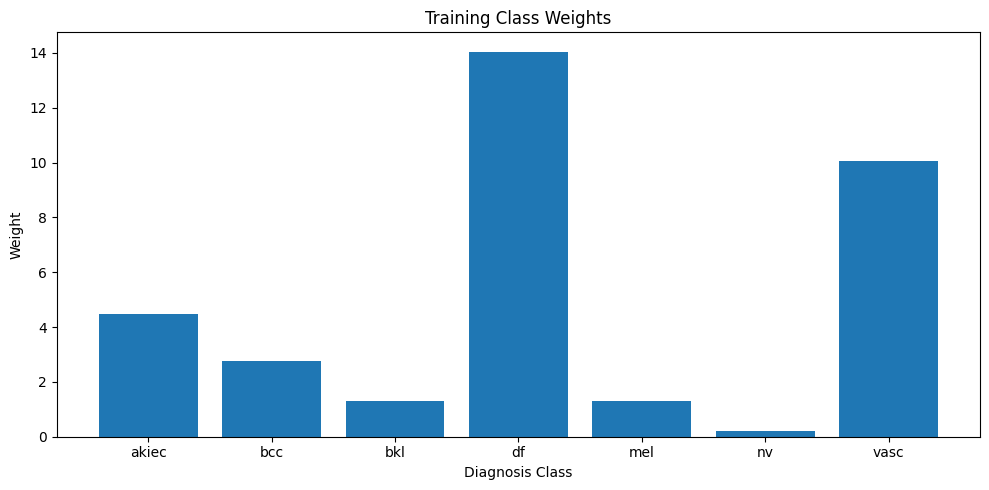

In [26]:
# Visual class weights
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    HAM10000_CLASSES,
    class_weights.numpy(),
)

plt.title(
    "Training Class Weights"
)

plt.xlabel(
    "Diagnosis Class"
)

plt.ylabel(
    "Weight"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "class_weights.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [27]:
# Check CUDA availability
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cpu


In [28]:
# DataLoader → Device smoke test
images, labels = next(
    iter(train_loader)
)

images = images.to(
    device
)

labels = labels.to(
    device
)

print(
    "Image device:",
    images.device
)

print(
    "Label device:",
    labels.device
)

print(
    "Batch image shape:",
    images.shape
)

Image device: cpu
Label device: cpu
Batch image shape: torch.Size([32, 3, 224, 224])


In [29]:
# Processing summary
print("=" * 70)
print("HAM10000 PREPROCESSING & AUGMENTATION SUMMARY")
print("=" * 70)

print(f"""
Framework:
    PyTorch / torchvision

Image size:
    {IMAGE_SIZE} x {IMAGE_SIZE}

Number of classes:
    {len(HAM10000_CLASSES)}

Training images:
    {len(train_dataset):,}

Validation images:
    {len(val_dataset):,}

Test images:
    {len(test_dataset):,}

Training preprocessing:
    - RandomResizedCrop
    - RandomHorizontalFlip
    - RandomVerticalFlip
    - RandomRotation
    - ColorJitter
    - ToTensor
    - ImageNet normalization

Validation/Test preprocessing:
    - Resize
    - ToTensor
    - ImageNet normalization

Batch size:
    {BATCH_SIZE}

Training shuffle:
    True

Validation/Test shuffle:
    False

Important:
    - Dataset splits from Part 3 are preserved.
    - Augmentation is applied only to training data.
    - Validation and test transforms are deterministic.
    - All images are converted to RGB.
    - Class labels use one fixed mapping across all splits.
""")

HAM10000 PREPROCESSING & AUGMENTATION SUMMARY

Framework:
    PyTorch / torchvision

Image size:
    224 x 224

Number of classes:
    7

Training images:
    6,981

Validation images:
    1,532

Test images:
    1,502

Training preprocessing:
    - RandomResizedCrop
    - RandomHorizontalFlip
    - RandomVerticalFlip
    - RandomRotation
    - ColorJitter
    - ToTensor
    - ImageNet normalization

Validation/Test preprocessing:
    - Resize
    - ToTensor
    - ImageNet normalization

Batch size:
    32

Training shuffle:
    True

Validation/Test shuffle:
    False

Important:
    - Dataset splits from Part 3 are preserved.
    - Augmentation is applied only to training data.
    - Validation and test transforms are deterministic.
    - All images are converted to RGB.
    - Class labels use one fixed mapping across all splits.

